# 04 - Evaluation
Load training results for Stage 1 and Stage 2, compare metrics, and inspect confusion matrices and result plots.

In [1]:
import sys
sys.path.append('..')

import os

from src.utils.evaluation import (
    load_results,
    plot_train_val_curves,
    plot_metric_comparison_bar,
    show_saved_image,
)

STAGE1_LOG_DIR = '../outputs/logs/stage-1'
STAGE2_LOG_DIR = '../outputs/logs/stage-2'

## Load results.csv for both stages

In [2]:
stage1_df = load_results(STAGE1_LOG_DIR)
stage2_df = load_results(STAGE2_LOG_DIR)

stage1_df.tail()

,epoch,time,train/ce_loss,train/dice_loss,train/aux_loss,metrics/mIoU,metrics/pixel_acc,val/ce_loss,val/dice_loss,val/aux_loss,lr/pg0,lr/pg1,lr/pg2
17,18,1601.82,0.15036,0.09512,0.05922,0.64450,0.89799,0.26434,0.29482,0,0.000832,0.000832,0.000832
18,19,1688.38,0.15711,0.09461,0.06097,0.68028,0.91496,0.23817,0.27302,0,0.000822,0.000822,0.000822
19,20,1775.59,0.14471,0.09113,0.05735,0.67680,0.91654,0.26712,0.27100,0,0.000812,0.000812,0.000812
20,21,1861.70,0.14012,0.08638,0.05522,0.68185,0.90669,0.26293,0.26315,0,0.000802,0.000802,0.000802
21,22,1948.85,0.13868,0.08631,0.05445,0.65171,0.91675,0.31324,0.27623,0,0.000792,0.000792,0.000792


In [3]:
stage2_df.tail()

,epoch,time,train/ce_loss,train/dice_loss,train/aux_loss,metrics/mIoU,metrics/pixel_acc,val/ce_loss,val/dice_loss,val/aux_loss,lr/pg0,lr/pg1,lr/pg2
21,22,3680.28,0.16550,0.11422,0.06454,0.57570,0.90873,0.27046,0.35103,0,0.000584,0.000584,0.000584
22,23,3844.77,0.16770,0.11426,0.06480,0.48179,0.85664,0.49227,0.44326,0,0.000564,0.000564,0.000564
23,24,4009.19,0.16417,0.11013,0.06361,0.55972,0.90053,0.32087,0.37409,0,0.000545,0.000545,0.000545
24,25,4173.21,0.14863,0.10194,0.05831,0.55814,0.90181,0.33669,0.36223,0,0.000525,0.000525,0.000525
25,26,4337.77,0.15056,0.10297,0.05857,0.56807,0.89941,0.35027,0.37425,0,0.000505,0.000505,0.000505


## Train vs Validation curves

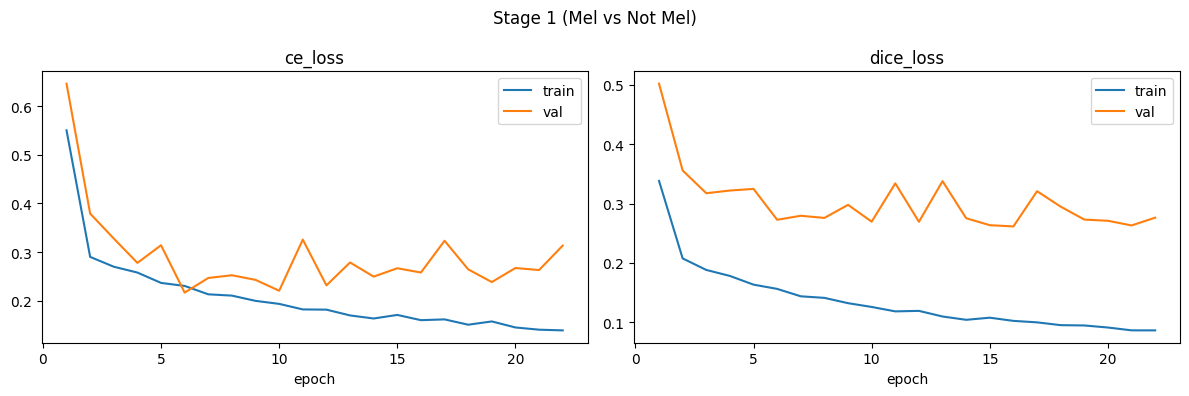

In [4]:
plot_train_val_curves(stage1_df, metrics=['ce_loss', 'dice_loss'], title='Stage 1 (Mel vs Not Mel)')

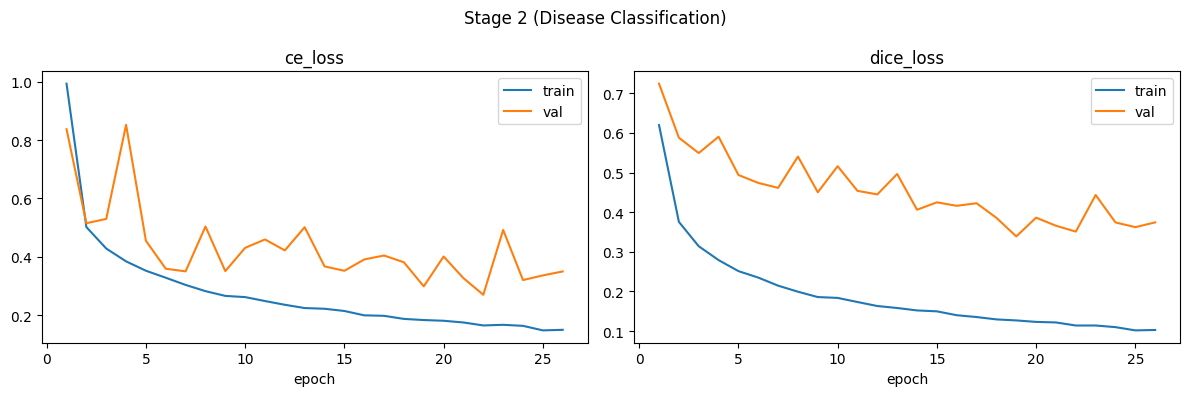

In [5]:
plot_train_val_curves(stage2_df, metrics=['ce_loss', 'dice_loss'], title='Stage 2 (Disease Classification)')

## mIoU comparison between Stage 1 and Stage 2

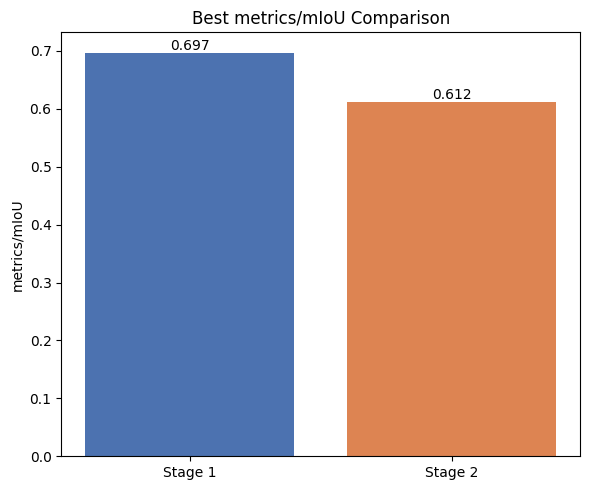

In [6]:
results_dict = {
    'Stage 1': stage1_df,
    'Stage 2': stage2_df,
}

plot_metric_comparison_bar(results_dict, metric_col='metrics/mIoU')

## Confusion Matrices

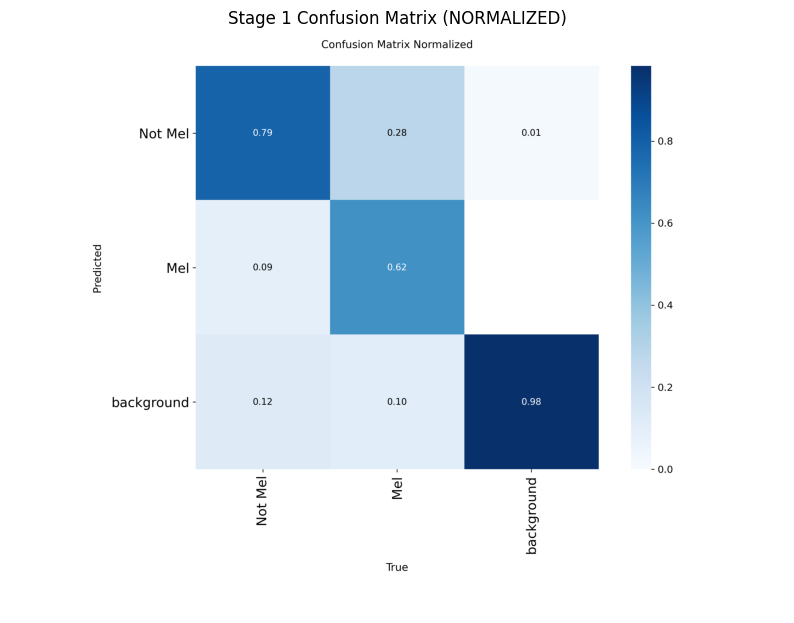

In [8]:
show_saved_image(os.path.join(STAGE1_LOG_DIR, 'confusion_matrix_normalized.png'), title='Stage 1 Confusion Matrix (NORMALIZED)')

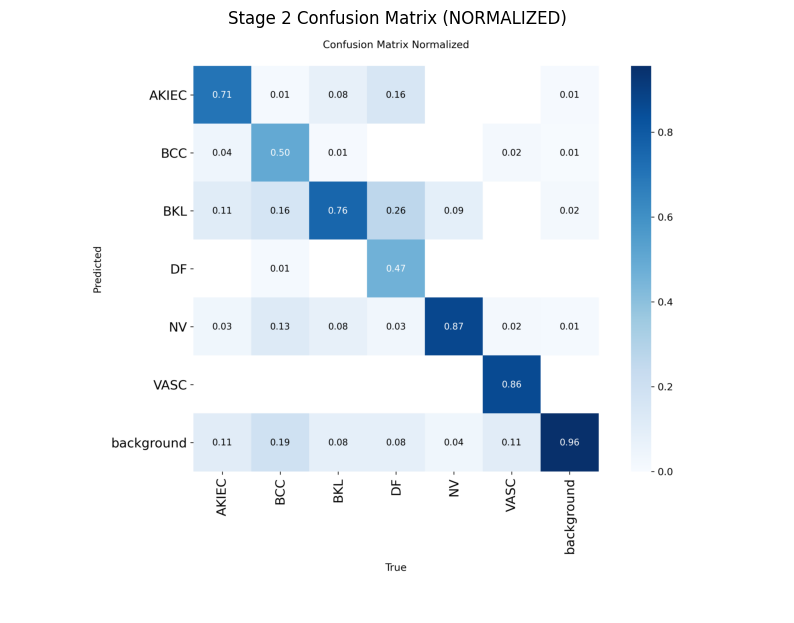

In [9]:
show_saved_image(os.path.join(STAGE2_LOG_DIR, 'confusion_matrix_normalized.png'), title='Stage 2 Confusion Matrix (NORMALIZED)')

## Result Plots (sample predictions saved during training)

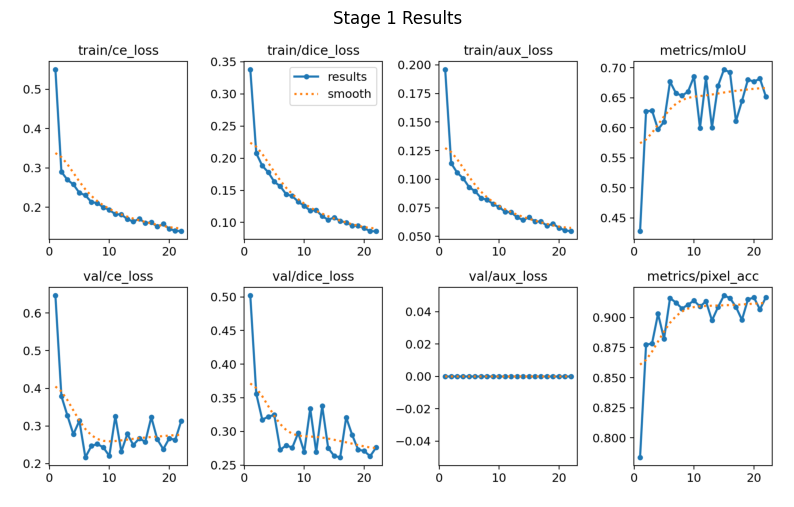

In [10]:
show_saved_image(os.path.join(STAGE1_LOG_DIR, 'results.png'), title='Stage 1 Results')

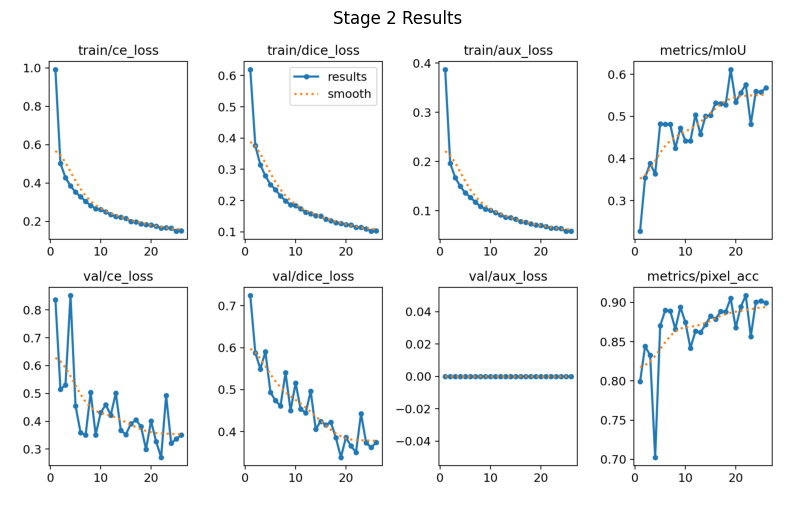

In [11]:
show_saved_image(os.path.join(STAGE2_LOG_DIR, 'results.png'), title='Stage 2 Results')

## Pixel Accuracy comparison (extra metric worth tracking alongside mIoU)

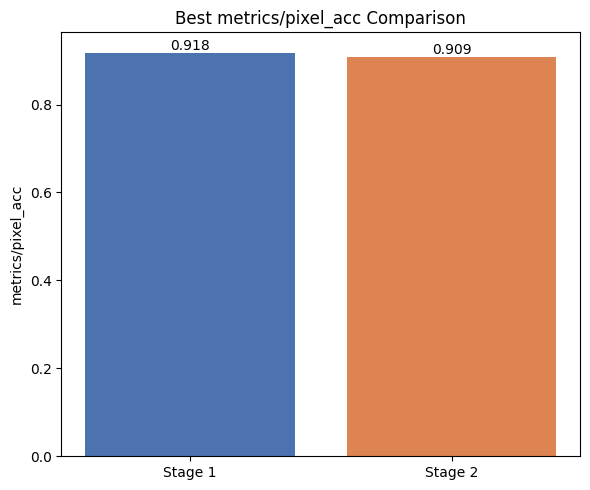

In [12]:
plot_metric_comparison_bar(results_dict, metric_col='metrics/pixel_acc')